In [1]:
print("Notebook working")


Notebook working


In [2]:
import os

base_path = "/home/moaz/projects/Email forensics/Datasets"

print("Nazario files:", os.listdir(base_path + "/nazario"))
print("SpamAssassin files:", os.listdir(base_path + "/spamassassin"))

FileNotFoundError: [Errno 2] No such file or directory: '/home/moaz/projects/Email forensics/Datasets/nazario'

In [ ]:
import mailbox

nazario_file = "/home/moaz/projects/Email forensics/Datasets/nazario/20051114.mbox"

mbox = mailbox.mbox(nazario_file)

print("Total emails in Nazario:", len(mbox))

FileNotFoundError: [Errno 2] No such file or directory: '/home/moaz/projects/Email forensics/Datasets/nazario/20051114.mbox'

In [ ]:
import os

spamassassin_ham = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_easy_ham"

print("Total ham emails:", len(os.listdir(spamassassin_ham)))

Total ham emails: 1


In [ ]:
import os

spamassassin_ham = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_easy_ham"

print(os.listdir(spamassassin_ham))

['easy_ham']


In [ ]:
ham_folder = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_easy_ham/easy_ham"

print("Total ham emails:", len(os.listdir(ham_folder)))

Total ham emails: 2551


In [ ]:
sample_file = os.listdir(ham_folder)[0]

with open(os.path.join(ham_folder, sample_file), "r", errors="ignore") as f:
    email_text = f.read()

print(email_text[:1000])

From 0xdeadbeef-request@petting-zoo.net  Thu Oct  3 12:22:47 2002
Return-Path: <0xdeadbeef-request@petting-zoo.net>
Delivered-To: yyyy@localhost.example.com
Received: from localhost (jalapeno [127.0.0.1])
	by jmason.org (Postfix) with ESMTP id 3592216F03
	for <jm@localhost>; Thu,  3 Oct 2002 12:22:47 +0100 (IST)
Received: from jalapeno [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for jm@localhost (single-drop); Thu, 03 Oct 2002 12:22:47 +0100 (IST)
Received: from petting-zoo.net (IDENT:postfix@petting-zoo.net
    [64.166.12.219]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id
    g9326sK10458 for <jm-deadbeef@jmason.org>; Thu, 3 Oct 2002 03:06:54 +0100
Received: by petting-zoo.net (Postfix, from userid 1004) id 42441EA2E;
    Wed,  2 Oct 2002 19:07:00 -0700 (PDT)
Old-Return-Path: <gkm@petting-zoo.net>
Delivered-To: 0xdeadbeef@petting-zoo.net
Received: from petting-zoo.net (localhost [127.0.0.1]) by petting-zoo.net
    (Postfix) with ESMTP id 21672EA0A; Wed,  2 Oct 2002 

In [ ]:
import os

ham_folder = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_easy_ham/easy_ham"

In [ ]:
sample_file = os.listdir(ham_folder)[0]

with open(os.path.join(ham_folder, sample_file), "r", errors="ignore") as f:
    email_text = f.read()

print(email_text[:1000])


From 0xdeadbeef-request@petting-zoo.net  Thu Oct  3 12:22:47 2002
Return-Path: <0xdeadbeef-request@petting-zoo.net>
Delivered-To: yyyy@localhost.example.com
Received: from localhost (jalapeno [127.0.0.1])
	by jmason.org (Postfix) with ESMTP id 3592216F03
	for <jm@localhost>; Thu,  3 Oct 2002 12:22:47 +0100 (IST)
Received: from jalapeno [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for jm@localhost (single-drop); Thu, 03 Oct 2002 12:22:47 +0100 (IST)
Received: from petting-zoo.net (IDENT:postfix@petting-zoo.net
    [64.166.12.219]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id
    g9326sK10458 for <jm-deadbeef@jmason.org>; Thu, 3 Oct 2002 03:06:54 +0100
Received: by petting-zoo.net (Postfix, from userid 1004) id 42441EA2E;
    Wed,  2 Oct 2002 19:07:00 -0700 (PDT)
Old-Return-Path: <gkm@petting-zoo.net>
Delivered-To: 0xdeadbeef@petting-zoo.net
Received: from petting-zoo.net (localhost [127.0.0.1]) by petting-zoo.net
    (Postfix) with ESMTP id 21672EA0A; Wed,  2 Oct 2002 

In [ ]:
from email import message_from_string

msg = message_from_string(email_text)

print("Subject:", msg["Subject"])
print("From:", msg["From"])
print("To:", msg["To"])

Subject: New $199 PC Doesn't Do Windows
From: gkm@petting-zoo.net (glen mccready)
To: 0xdeadbeef@petting-zoo.net


In [ ]:
if msg.is_multipart():
    body = ""
    for part in msg.walk():
        if part.get_content_type() == "text/plain":
            body += part.get_payload(decode=True).decode(errors="ignore")
else:
    body = msg.get_payload(decode=True).decode(errors="ignore")

print(body[:1000])


Forwarded-by: Monty Solomon <monty@roscom.com>

     New $199 PC Doesn't Do Windows
     - Oct 2, 2002 03:53 PM (AP Online)
     - http://finance.lycos.com/home/news/story.asp?story=28928829

By MATTHEW FORDAHL
AP Technology Writer
  
  It's been about 20 years since a new Atari 400 or Commodore Vic
20 could be had for less than $200. Even then, those relics were
well on their way from bargain bins to the dust bin of PC history.
  Since then, few if any new computers have sold for less than
$200. Any that did were seriously outdated or inoperable.
  Now, in a challenge to established tech giants, several upstarts
have banded together to create a PC that retails for $199.86.
  It doesn't do Windows. In fact, it doesn't do a lot of things.
  The Microtel SYSMAR710, sold only at Wal-Mart's online store,
runs on a Linux operating system variant called Lindows, which has
been hyped as a new choice for consumers who want to break away
from the Microsoft monopoly.

...

     - http://finance

In [ ]:
import re

clean_text = re.sub(r"http\S+", "", body)      # remove links
clean_text = re.sub(r"[^a-zA-Z\s]", " ", clean_text)  # keep letters only
clean_text = re.sub(r"\s+", " ", clean_text)   # remove extra spaces

print(clean_text[:1000])

 Forwarded by Monty Solomon monty roscom com New PC Doesn t Do Windows Oct PM AP Online By MATTHEW FORDAHL AP Technology Writer It s been about years since a new Atari or Commodore Vic could be had for less than Even then those relics were well on their way from bargain bins to the dust bin of PC history Since then few if any new computers have sold for less than Any that did were seriously outdated or inoperable Now in a challenge to established tech giants several upstarts have banded together to create a PC that retails for It doesn t do Windows In fact it doesn t do a lot of things The Microtel SYSMAR sold only at Wal Mart s online store runs on a Linux operating system variant called Lindows which has been hyped as a new choice for consumers who want to break away from the Microsoft monopoly 


In [ ]:
ham_texts = []

for file in os.listdir(ham_folder):
    try:
        with open(os.path.join(ham_folder, file), "r", errors="ignore") as f:
            email_text = f.read()

        msg = message_from_string(email_text)

        if msg.is_multipart():
            body = ""
            for part in msg.walk():
                if part.get_content_type() == "text/plain":
                    body += part.get_payload(decode=True).decode(errors="ignore")
        else:
            body = msg.get_payload(decode=True).decode(errors="ignore")

        clean_text = re.sub(r"http\S+", "", body)
        clean_text = re.sub(r"[^a-zA-Z\s]", " ", clean_text)
        clean_text = re.sub(r"\s+", " ", clean_text)

        ham_texts.append(clean_text)

    except:
        continue

print("Total cleaned ham emails:", len(ham_texts))

Total cleaned ham emails: 2551


In [ ]:
spam_folder = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_spam/spam"
spam_texts = []

for file in os.listdir(spam_folder):
    try:
        with open(os.path.join(spam_folder, file), "r", errors="ignore") as f:
            email_text = f.read()

        msg = message_from_string(email_text)

        if msg.is_multipart():
            body = ""
            for part in msg.walk():
                if part.get_content_type() == "text/plain":
                    body += part.get_payload(decode=True).decode(errors="ignore")
        else:
            body = msg.get_payload(decode=True).decode(errors="ignore")

        clean_text = re.sub(r"http\S+", "", body)
        clean_text = re.sub(r"[^a-zA-Z\s]", " ", clean_text)
        clean_text = re.sub(r"\s+", " ", clean_text)

        spam_texts.append(clean_text)

    except:
        continue

print("Total cleaned spam emails:", len(spam_texts))

Total cleaned spam emails: 501


In [ ]:
print(os.listdir("/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_spam"))

['spam']


In [ ]:
spam_folder = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_spam/spam"

spam_texts = []

for file in os.listdir(spam_folder):
    try:
        with open(os.path.join(spam_folder, file), "r", errors="ignore") as f:
            email_text = f.read()

        msg = message_from_string(email_text)

        if msg.is_multipart():
            body = ""
            for part in msg.walk():
                if part.get_content_type() == "text/plain":
                    body += part.get_payload(decode=True).decode(errors="ignore")
        else:
            body = msg.get_payload(decode=True).decode(errors="ignore")

        clean_text = re.sub(r"http\S+", "", body)
        clean_text = re.sub(r"[^a-zA-Z\s]", " ", clean_text)
        clean_text = re.sub(r"\s+", " ", clean_text)

        spam_texts.append(clean_text)

    except:
        continue

print("Total cleaned spam emails:", len(spam_texts))

Total cleaned spam emails: 501


In [ ]:
import pandas as pd

df_ham = pd.DataFrame({
    "text": ham_texts,
    "label": 0
})

df_spam = pd.DataFrame({
    "text": spam_texts,
    "label": 1
})

df = pd.concat([df_ham, df_spam], ignore_index=True)

print(df.shape)
df.head()

(3052, 2)


,text,label
0,Forwarded by Monty Solomon monty roscom com N...,0
1,Congrats in the end If they didn t have Max th...,0
2,Forwarded by Rob Windsor windsor warthog com ...,0
3,What I meant was that neither he nor anyone el...,0
4,URL Date Mon Sep GMT After posting my comment ...,0


In [ ]:
def forensic_check(text):
    text = text.lower()

    suspicious_keywords = ["verify", "login", "password", "bank", "urgent", "click"]

    score = 0

    # keyword check
    for word in suspicious_keywords:
        if word in text:
            score += 1

    # URL check
    if "http" in text:
        score += 1

    # length / weird patterns
    if len(text) > 500:
        score += 1

    return 1 if score >= 2 else 0

In [ ]:
f["forensic_pred"] = df["text"].apply(forensic_check)

TypeError: '_io.TextIOWrapper' object does not support item assignment

In [ ]:
%pip install pandas --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd

df_ham = pd.DataFrame({
    "text": ham_texts,
    "label": 0
})

df_spam = pd.DataFrame({
    "text": spam_texts,
    "label": 1
})

df = pd.concat([df_ham, df_spam], ignore_index=True)

print(df.shape)
df.head()

(3052, 2)


,text,label
0,Forwarded by Monty Solomon monty roscom com N...,0
1,Congrats in the end If they didn t have Max th...,0
2,Forwarded by Rob Windsor windsor warthog com ...,0
3,What I meant was that neither he nor anyone el...,0
4,URL Date Mon Sep GMT After posting my comment ...,0


In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,text,label
0,Once upon a time Hesty wrote Where you can see...,0
1,On Mon at Mike Masnick wrote In which world ar...,0
2,If anyone here is running null beta then you m...,0
3,URL Date T Medicine and health The discovery o...,0
4,URL Date T IMG MDN,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 2441
Test: 611


In [ ]:
%pip install scikit-learn --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 2441
Test: 611


In [ ]:
%pip install tensorflow --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import tensorflow as tf
print(tf.__version__)

I0000 00:00:1777123060.651370    8262 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777123062.956121    8262 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777123068.654411    8262 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0


In [ ]:
import os
os._exit(00)

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print("Train padded shape:", X_train_pad.shape)
print("Test padded shape:", X_test_pad.shape)

Train padded shape: (2441, 200)
Test padded shape: (611, 200)


In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 2441
Test: 611


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense

model = Sequential()

model.add(Embedding(input_dim=10000, output_dim=128, input_shape=(200,)))
model.add(Conv1D(64, 5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Bidirectional(GRU(64)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/home/moaz/projects/Email forensics/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,371,073 (5.23 MB)

 Trainable params: 1,371,073 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.8890 - loss: 0.2780 - val_accuracy: 0.9542 - val_loss: 0.1906
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.9848 - loss: 0.0473 - val_accuracy: 0.9820 - val_loss: 0.0676
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.9980 - loss: 0.0086 - val_accuracy: 0.9836 - val_loss: 0.0561
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9804 - val_loss: 0.0675
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 0.9853 - val_loss: 0.0584


In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9853 - loss: 0.0584
Test Accuracy: 0.9852700233459473


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print(cm)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
[[510   6]
 [  3  92]]


In [ ]:
import mailbox
import re

nazario_file = "/home/moaz/projects/Email forensics/Datasets/nazario/20051114.mbox"

mbox = mailbox.mbox(nazario_file)
print("Total Nazario emails:", len(mbox))

Total Nazario emails: 438


In [ ]:
nazario_texts = []

for message in mbox:
    if message.is_multipart():
        for part in message.walk():
            if part.get_content_type() == "text/plain":
                try:
                    nazario_texts.append(part.get_payload(decode=True).decode(errors="ignore"))
                except:
                    pass
    else:
        try:
            nazario_texts.append(message.get_payload(decode=True).decode(errors="ignore"))
        except:
            pass

print("Extracted Nazario texts:", len(nazario_texts))

Extracted Nazario texts: 297


In [ ]:
clean_nazario = []

for text in nazario_texts:
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    clean_nazario.append(text)

print("Clean Nazario:", len(clean_nazario))

Clean Nazario: 297


In [ ]:
nazario_labels = [1] * len(clean_nazario)

print("Labels:", len(nazario_labels))

Labels: 297


In [ ]:
all_texts = list(df["text"]) + clean_nazario
all_labels = list(df["label"]) + nazario_labels

print("Total texts:", len(all_texts))
print("Total labels:", len(all_labels))

Total texts: 3349
Total labels: 3349


In [ ]:
from sklearn.utils import shuffle

all_texts, all_labels = shuffle(all_texts, all_labels, random_state=42)

In [ ]:
import pandas as pd

df_final = pd.DataFrame({
    "text": all_texts,
    "label": all_labels
})

print(df_final.shape)
df_final.head()

(3349, 2)


,text,label
0,A New Theory on Mapping the New World By Guy ...,0
1,URL Date T Business Powergen yesterday shut do...,0
2,URL Date T Paris dispatch A growing number of ...,0
3,URL Date Not supplied The new ish of Strange H...,0
4,Not true on the choice part After three weeks...,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df_final["text"]
y = df_final["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(len(X_train), len(X_test))

2679 670


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print(X_train_pad.shape, X_test_pad.shape)

(2441, 200) (611, 200)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense

model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=128, input_shape=(200,)))
model.add(Conv1D(64, 5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Bidirectional(GRU(64)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/home/moaz/projects/Email forensics/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,371,073 (5.23 MB)

 Trainable params: 1,371,073 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 382ms/step - accuracy: 0.8802 - loss: 0.2718 - val_accuracy: 0.9851 - val_loss: 0.0495
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 375ms/step - accuracy: 0.9903 - loss: 0.0293 - val_accuracy: 0.9910 - val_loss: 0.0283
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 383ms/step - accuracy: 0.9985 - loss: 0.0080 - val_accuracy: 0.9910 - val_loss: 0.0256
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 371ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 0.9940 - val_loss: 0.0276
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 381ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9925 - val_loss: 0.0277


In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.9925 - loss: 0.0277
Test Accuracy: 0.9925373196601868


In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print(cm)

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step
[[511   3]
 [  2 154]]


In [ ]:
import os
import email
from email import policy

sample_path = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_easy_ham/easy_ham/" + os.listdir("/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_easy_ham/easy_ham")[0]

with open(sample_path, "r", errors="ignore") as f:
    msg = email.message_from_file(f, policy=policy.default)

print("From:", msg["From"])
print("To:", msg["To"])
print("Subject:", msg["Subject"])
print("Date:", msg["Date"])
print("Message-ID:", msg["Message-ID"])

From: gkm@petting-zoo.net
To: 0xdeadbeef@petting-zoo.net
Subject: New $199 PC Doesn't Do Windows
Date: Wed, 02 Oct 2002 19:06:58 -0700
Message-ID: <20021003020658.21672EA0A@petting-zoo.net>


In [ ]:
if msg.is_multipart():
    for part in msg.walk():
        if part.get_content_type() == "text/plain":
            try:
                body = part.get_payload(decode=True).decode(errors="ignore")
                print(body[:500])
            except:
                pass
else:
    body = msg.get_payload(decode=True).decode(errors="ignore")
    print(body[:500])


Forwarded-by: Monty Solomon <monty@roscom.com>

     New $199 PC Doesn't Do Windows
     - Oct 2, 2002 03:53 PM (AP Online)
     - http://finance.lycos.com/home/news/story.asp?story=28928829

By MATTHEW FORDAHL
AP Technology Writer
  
  It's been about 20 years since a new Atari 400 or Commodore Vic
20 could be had for less than $200. Even then, those relics were
well on their way from bargain bins to the dust bin of PC history.
  Since then, few if any new computers have sold for less than
$20


In [ ]:
received_headers = msg.get_all("Received")

if received_headers:
    for i, header in enumerate(received_headers):
        print(f"Received {i+1}:")
        print(header)
        print("\n")
else:
    print("No Received headers found")

Received 1:
from localhost (jalapeno [127.0.0.1])	by jmason.org (Postfix) with ESMTP id 3592216F03	for <jm@localhost>; Thu,  3 Oct 2002 12:22:47 +0100 (IST)


Received 2:
from jalapeno [127.0.0.1]	by localhost with IMAP (fetchmail-5.9.0)	for jm@localhost (single-drop); Thu, 03 Oct 2002 12:22:47 +0100 (IST)


Received 3:
from petting-zoo.net (IDENT:postfix@petting-zoo.net    [64.166.12.219]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id    g9326sK10458 for <jm-deadbeef@jmason.org>; Thu, 3 Oct 2002 03:06:54 +0100


Received 4:
by petting-zoo.net (Postfix, from userid 1004) id 42441EA2E;    Wed,  2 Oct 2002 19:07:00 -0700 (PDT)


Received 5:
from petting-zoo.net (localhost [127.0.0.1]) by petting-zoo.net    (Postfix) with ESMTP id 21672EA0A; Wed,  2 Oct 2002 19:06:58 -0700 (PDT)




In [ ]:
import re

ips = []

for header in received_headers:
    found = re.findall(r'\d+\.\d+\.\d+\.\d+', header)
    ips.extend(found)

print("Extracted IPs:", ips)

Extracted IPs: ['127.0.0.1', '127.0.0.1', '64.166.12.219', '127.0.0.1']


In [ ]:
real_ips = [ip for ip in ips if ip != "127.0.0.1"]

print("Possible sender IP:", real_ips[0])

Possible sender IP: 64.166.12.219


In [ ]:
import re

urls = re.findall(r'http\S+', body)

print("URLs found:", urls)

URLs found: ['http://finance.lycos.com/home/news/story.asp?story=28928829', 'http://finance.lycos.com/home/news/story.asp?story=28928829']


In [ ]:
keywords = ["verify", "login", "password", "bank", "urgent", "click"]

found = []

for word in keywords:
    if word in body.lower():
        found.append(word)

print("Suspicious words:", found)

Suspicious words: []


In [ ]:
email_data = {
    "from": msg["From"],
    "to": msg["To"],
    "subject": msg["Subject"],
    "date": msg["Date"],
    "sender_ip": real_ips[0],
    "urls": urls,
    "suspicious_words": found
}

print(email_data)

{'from': 'gkm@petting-zoo.net', 'to': '0xdeadbeef@petting-zoo.net', 'subject': "New $199 PC Doesn't Do Windows", 'date': 'Wed, 02 Oct 2002 19:06:58 -0700', 'sender_ip': '64.166.12.219', 'urls': ['http://finance.lycos.com/home/news/story.asp?story=28928829', 'http://finance.lycos.com/home/news/story.asp?story=28928829'], 'suspicious_words': []}


In [ ]:
spam_folder = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_spam/spam/"
spam_file = os.listdir(spam_folder)[0]
sample_path = spam_folder + spam_file

with open(sample_path, "r", errors="ignore") as f:
    msg = email.message_from_file(f, policy=policy.default)

print("From:", msg["From"])
print("To:", msg["To"])
print("Subject:", msg["Subject"])
print("Date:", msg["Date"])
print("Message-ID:", msg["Message-ID"])

From: sunday68@bluemail.dk
To: paulifree@hotmail.com
Subject: FORTUNE 500 WORK AT HOME REPS NEEDED!
Date: Fri, 20 Sep 2002 04:47:45 +0100
Message-ID: <004e01e10eca$6576b5b2$0dd22cc2@qtnqof>


In [ ]:
# -------- BODY EXTRACTION --------
if msg.is_multipart():
    for part in msg.walk():
        if part.get_content_type() == "text/plain":
            try:
                body = part.get_payload(decode=True).decode(errors="ignore")
            except:
                pass
else:
    body = msg.get_payload(decode=True).decode(errors="ignore")

print(body[:300])


# -------- RECEIVED HEADERS --------
received_headers = msg.get_all("Received")

print("\nReceived headers:")
for header in received_headers:
    print(header)


# -------- IP EXTRACTION --------
import re

ips = []
for header in received_headers:
    found = re.findall(r'\d+\.\d+\.\d+\.\d+', header)
    ips.extend(found)

real_ips = [ip for ip in ips if ip != "127.0.0.1"]

print("\nSender IP:", real_ips[0] if real_ips else "Not found")


# -------- URL EXTRACTION --------
urls = re.findall(r'http\S+', body)
print("\nURLs:", urls)


# -------- KEYWORD CHECK --------
keywords = ["verify", "login", "password", "bank", "urgent", "click"]

found_words = []
for word in keywords:
    if word in body.lower():
        found_words.append(word)

print("\nSuspicious words:", found_words)


# -------- FINAL DICTIONARY --------
email_data = {
    "from": msg["From"],
    "subject": msg["Subject"],
    "sender_ip": real_ips[0] if real_ips else None,
    "urls": urls,
    "suspicious_words": found_words
}

print("\nFinal Output:\n", email_data)

Immediate Help Needed.  We are a fortune 500 company that is 
growing at a tremendous rate of over 1000% per year. We simply cannot 
keep up. We are looking for motivated individuals who are looking to 
earn a substantial income working from home. 

This is a real opportunity to make an excellent in

Received headers:
from localhost (jalapeno [127.0.0.1])	by zzzzason.org (Postfix) with ESMTP id 8FD3716F03	for <zzzz@localhost>; Fri, 20 Sep 2002 11:41:21 +0100 (IST)
from jalapeno [127.0.0.1]	by localhost with IMAP (fetchmail-5.9.0)	for zzzz@localhost (single-drop); Fri, 20 Sep 2002 11:41:21 +0100 (IST)
from webnote.net (mail.webnote.net [193.120.211.219]) by    dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g8K3lHC19280 for    <zzzz@jmason.org>; Fri, 20 Sep 2002 04:47:17 +0100
from bluemail.dk (host230-95.pool21756.interbusiness.it    [217.56.95.230]) by webnote.net (8.9.3/8.9.3) with SMTP id EAA04124;    Fri, 20 Sep 2002 04:47:45 +0100

Sender IP: 193.120.211.219

URLs: ['http://ter.

In [ ]:
results = []

folder = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_spam/spam/"

for filename in os.listdir(folder):
    file_path = folder + filename
    
    with open(file_path, "r", errors="ignore") as f:
        msg = email.message_from_file(f, policy=policy.default)
    
    # BODY
    body = ""
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/plain":
                try:
                    body = part.get_payload(decode=True).decode(errors="ignore")
                except:
                    pass
    else:
        body = msg.get_payload(decode=True).decode(errors="ignore")
    
    # HEADERS → IP
    received_headers = msg.get_all("Received") or []
    ips = []
    for header in received_headers:
        ips.extend(re.findall(r'\d+\.\d+\.\d+\.\d+', header))
    
    real_ips = [ip for ip in ips if ip != "127.0.0.1"]
    
    # URLS
    urls = re.findall(r'http\S+', body)
    
    # KEYWORDS
    keywords = ["verify", "login", "password", "bank", "urgent", "click"]
    found_words = [word for word in keywords if word in body.lower()]
    
    results.append({
        "sender_ip": real_ips[0] if real_ips else None,
        "urls": urls,
        "suspicious_words": found_words
    })

print("Total emails processed:", len(results))

Total emails processed: 501


In [ ]:
import pandas as pd

df_spam_results = pd.DataFrame(results)

print(df_spam_results.head())
print(df_spam_results.shape)

         sender_ip                                               urls  \
0  193.120.211.219  [http://ter.netblah.com:27000, http://ter.netb...   
1     213.41.78.25  [http://61.145.116.186/user0201/index.asp?Afft...   
2  193.120.211.219  [http-equiv="Content-Type", http://www.jeweldi...   
3  193.120.211.219  [http://ww1.bestoffersonthenet.com/termlifequo...   
4  193.120.211.219  [http://marketing-fashion.com/user0201/index.a...   

  suspicious_words  
0          [click]  
1               []  
2          [click]  
3               []  
4               []  
(501, 3)


In [ ]:
ham_results = []

ham_folder = "/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_easy_ham/easy_ham/"

for filename in os.listdir(ham_folder):
    file_path = ham_folder + filename
    
    with open(file_path, "r", errors="ignore") as f:
        msg = email.message_from_file(f, policy=policy.default)
    
    # BODY
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/plain":
                try:
                    body = part.get_payload(decode=True).decode(errors="ignore")
                except:
                    body = ""
    else:
        body = msg.get_payload(decode=True).decode(errors="ignore")
    
    # RECEIVED → IPs
    received_headers = msg.get_all("Received") or []
    ips = []
    for header in received_headers:
        ips.extend(re.findall(r'\d+\.\d+\.\d+\.\d+', header))
    
    real_ips = [ip for ip in ips if ip != "127.0.0.1"]
    
    # URLS
    urls = re.findall(r'http\S+', body)
    
    # KEYWORDS
    keywords = ["verify", "login", "password", "bank", "urgent", "click"]
    found_words = [word for word in keywords if word in body.lower()]
    
    ham_results.append({
        "sender_ip": real_ips[0] if real_ips else None,
        "urls": urls,
        "suspicious_words": found_words
    })

print(len(ham_results))

2551


In [ ]:
df_ham_results = pd.DataFrame(ham_results)

print(df_ham_results.head())
print(df_ham_results.shape)

       sender_ip                                               urls  \
0  64.166.12.219  [http://finance.lycos.com/home/news/story.asp?...   
1  64.161.22.236  [http://www.infoworld.com/articles/ct/xml/02/0...   
2  64.166.12.219                                                 []   
3  64.161.22.236     [http://photos.msn.com/support/worldwide.aspx]   
4            NaN  [http://scriptingnews.userland.com/backissues/...   

   suspicious_words  
0                []  
1  [password, bank]  
2                []  
3                []  
4                []  
(2551, 3)


In [ ]:
df_spam_results["label"] = 1   # spam
df_ham_results["label"] = 0    # ham

df_final = pd.concat([df_spam_results, df_ham_results], ignore_index=True)

print(df_final.shape)
df_final.head()

(3052, 4)


,sender_ip,urls,suspicious_words,label
0,193.120.211.219,"[http://ter.netblah.com:27000, http://ter.netb...",[click],1
1,213.41.78.25,[http://61.145.116.186/user0201/index.asp?Afft...,[],1
2,193.120.211.219,"[http-equiv=""Content-Type"", http://www.jeweldi...",[click],1
3,193.120.211.219,[http://ww1.bestoffersonthenet.com/termlifequo...,[],1
4,193.120.211.219,[http://marketing-fashion.com/user0201/index.a...,[],1


In [ ]:
df_final.to_csv("forensic_dataset.csv", index=False)

In [ ]:
import os
print(os.listdir())

['setup_test.py', 'forensic_dataset.csv', 'email_forensics.ipynb', 'Datasets', '.venv']


In [ ]:
df_final["url_count"] = df_final["urls"].apply(lambda x: len(x))
df_final["suspicious_count"] = df_final["suspicious_words"].apply(lambda x: len(x))

df_final.head()

,sender_ip,urls,suspicious_words,label,url_count,suspicious_count
0,193.120.211.219,"[http://ter.netblah.com:27000, http://ter.netb...",[click],1,3,1
1,213.41.78.25,[http://61.145.116.186/user0201/index.asp?Afft...,[],1,2,0
2,193.120.211.219,"[http-equiv=""Content-Type"", http://www.jeweldi...",[click],1,5,1
3,193.120.211.219,[http://ww1.bestoffersonthenet.com/termlifequo...,[],1,2,0
4,193.120.211.219,[http://marketing-fashion.com/user0201/index.a...,[],1,2,0


In [ ]:
X = df_final[["url_count", "suspicious_count"]]
y = df_final["label"]

print(X.head())
print(y.head())

   url_count  suspicious_count
0          3                 1
1          2                 0
2          5                 1
3          2                 0
4          2                 0
0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# results
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8412438625204582
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       497
           1       0.74      0.23      0.35       114

    accuracy                           0.84       611
   macro avg       0.80      0.60      0.63       611
weighted avg       0.83      0.84      0.81       611



In [ ]:
model = RandomForestClassifier(class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8314238952536824
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       497
           1       0.56      0.46      0.50       114

    accuracy                           0.83       611
   macro avg       0.72      0.69      0.70       611
weighted avg       0.82      0.83      0.82       611



In [ ]:
df_final["risk_score"] = df_final["url_count"] + df_final["suspicious_count"]

In [ ]:
import mailbox

nazario_file = "/home/moaz/projects/Email forensics/Datasets/nazario/20051114.mbox"

mbox = mailbox.mbox(nazario_file)

msg = mbox[0]   # first email

print(msg["From"])
print(msg["Subject"])

"aw-confirm@ebay.com" <aw-confirm@ebay.com>
TKO Notice: ***Urgent Safeharbor Department Notice*** 


In [ ]:
body = ""

if msg.is_multipart():
    for part in msg.walk():
        if part.get_content_type() == "text/plain":
            try:
                body = part.get_payload(decode=True).decode(errors="ignore")
            except:
                pass
else:
    body = msg.get_payload(decode=True).decode(errors="ignore")

print(body[:500])

In [ ]:
body = ""

if msg.is_multipart():
    for part in msg.walk():
        if part.get_content_type() in ["text/plain", "text/html"]:
            try:
                body = part.get_payload(decode=True).decode(errors="ignore")
            except:
                pass
else:
    body = msg.get_payload(decode=True).decode(errors="ignore")

print(body[:500])

<html>
<head>
<!--   extraneous meta tag removed by ebay code  -->
<!--srcId: SignIn-->
<META HTTP-EQUIV="Content-Type" CONTENT="text/html; charset=ISO-8859-1">
<title>eBay Suspension</title>
</head>
<body bgcolor="#ffffff">
<table border="0" cellspacing="0" cellpadding="0"
bgcolor="#FFFFFF"><tr><td><img
src="http://pics.ebaystatic.com/aw/pics/spacer.gif" width="180"
height="1"></td></tr><tr><td>
<a href="http://pages.ebay.com/"><img
src="http://pics.ebaystatic.com/aw/pics/register/HeaderRegiste


In [ ]:
import re

# extract raw urls
urls = re.findall(r'https?://[^\s"\'>]+', body)

# clean (remove duplicates + junk)
clean_urls = list(set(urls))

print("Clean URLs:", clean_urls[:5])

Clean URLs: ['http://pics.ebaystatic.com/aw/pics/spacer.gif', 'http://pics.ebaystatic.com/aw/pics/register/HeaderRegister_387x40.gif', 'http://cgi1.ebay.com/aw-cgi/ebayISAPI.dll?UPdate</a', 'http://include.ebaystatic.com/aw/pics/js/stats/ss.js', 'http://pages.ebay.com/']


In [ ]:
received_headers = msg.get_all("Received") or []

ips = []
for header in received_headers:
    ips.extend(re.findall(r'\d+\.\d+\.\d+\.\d+', header))

real_ips = [ip for ip in ips if not ip.startswith(("127.", "10.", "192.168"))]

print("Sender IP:", real_ips[0] if real_ips else None)

Sender IP: 195.245.214.83


In [ ]:
keywords = ["verify", "login", "password", "account", "bank", "urgent"]

found_words = [word for word in keywords if word in body.lower()]

print("Suspicious words:", found_words)

Suspicious words: ['verify', 'account']


In [ ]:
email_data = {
    "from": msg["From"],
    "subject": msg["Subject"],
    "sender_ip": real_ips[0] if real_ips else None,
    "urls": clean_urls,
    "suspicious_words": found_words
}

print(email_data)

{'from': '"aw-confirm@ebay.com" <aw-confirm@ebay.com>', 'subject': 'TKO Notice: ***Urgent Safeharbor Department Notice*** ', 'sender_ip': '195.245.214.83', 'urls': ['http://pics.ebaystatic.com/aw/pics/spacer.gif', 'http://pics.ebaystatic.com/aw/pics/register/HeaderRegister_387x40.gif', 'http://cgi1.ebay.com/aw-cgi/ebayISAPI.dll?UPdate</a', 'http://include.ebaystatic.com/aw/pics/js/stats/ss.js', 'http://pages.ebay.com/', 'http://pages.ebay.com/help/policies/user-agreement.html', 'http://pages.ebay.com/help/policies/privacy-policy.html', 'http://include.ebaystatic.com/aw/pics/js/stats/ss2.js', 'http://pages.ebay.com/help/new/signin.html', 'http://pics.ebaystatic.com/aw/pics/truste_button.gif', 'http://pics.ebaystatic.com/aw/pics/listings/questionMark_14x14.gif', 'http://70.96.188.24/~backfoul/secure/aw-cgi/DllUpdate/ws2/ISAPIDll/signin/error.html', 'http://pics.ebaystatic.com/aw/pics/sitewide/leftLine_16x3.gif'], 'suspicious_words': ['verify', 'account']}


In [ ]:
msg = mbox[1]

In [ ]:
print("From:", msg["From"])
print("Subject:", msg["Subject"])

From: "" <online-banking@lasallebank.com>
Subject: ATM cards attention. conformation code? yftue  fvkg ts r


In [ ]:
body = ""

if msg.is_multipart():
    for part in msg.walk():
        if part.get_content_type() in ["text/plain", "text/html"]:
            try:
                body = part.get_payload(decode=True).decode(errors="ignore")
            except:
                pass
else:
    body = msg.get_payload(decode=True).decode(errors="ignore")

print(body[:500])

&nbsp;<body bgcolor=#ffffff><div align="left">
<TABLE width=520 cellpadding=0 cellspacing=0 bgcolor=#ffffff class=main>
<TR><TD align="left">
<p style="margin-top: 0; margin-bottom: 0" align="left">
Dear LaSalle Member,</p>
<p style="margin-top: 0; margin-bottom: 0" align="left">&nbsp;</p>
<p style="margin-top: 0; margin-bottom: 0" align="left">As part of our continuing commitment to protect your account and to reduce
the instance of fraud on our website, we are undertaking a period review of ou


In [ ]:
import re

urls = re.findall(r'https?://[^\s"<>]+', body)
clean_urls = list(set(urls))

print("Clean URLs:", clean_urls[:5])

Clean URLs: ['http://lasallebank-online.com/', 'https://www.lasallebank-online.com/']


In [ ]:
received_headers = msg.get_all("Received") or []

ips = []
for header in received_headers:
    ips.extend(re.findall(r'\d+\.\d+\.\d+\.\d+', header))

real_ips = [ip for ip in ips if not ip.startswith(("127.", "10.", "192.168"))]

print("Sender IP:", real_ips[0] if real_ips else None)

Sender IP: 68.60.190.245


In [ ]:
keywords = ["verify", "login", "password", "account", "bank", "urgent"]

found_words = [word for word in keywords if word in body.lower()]

print("Suspicious words:", found_words)

Suspicious words: ['verify', 'account', 'bank']


In [ ]:
email_data = {
    "from": msg["From"],
    "subject": msg["Subject"],
    "sender_ip": real_ips[0] if real_ips else None,
    "urls": clean_urls,
    "suspicious_words": found_words
}

print(email_data)

{'from': '"" <online-banking@lasallebank.com>', 'subject': 'ATM cards attention. conformation code? yftue  fvkg ts r', 'sender_ip': '68.60.190.245', 'urls': ['http://lasallebank-online.com/', 'https://www.lasallebank-online.com/'], 'suspicious_words': ['verify', 'account', 'bank']}


In [ ]:
msg = mbox[2]

In [ ]:

print("From:", msg["From"])
print("Subject:", msg["Subject"])

From: "" <support-team@lasallebank.com>
Subject: Imporant information for LaSalle Bank Customers conformation code? rouhevzrkjd mp


In [ ]:
body = ""

if msg.is_multipart():
    for part in msg.walk():
        if part.get_content_type() in ["text/plain", "text/html"]:
            try:
                body = part.get_payload(decode=True).decode(errors="ignore")
            except:
                pass
else:
    body = msg.get_payload(decode=True).decode(errors="ignore")

print(body[:500])

&nbsp;<body bgcolor=#ffffff><div align="left">
<TABLE width=520 cellpadding=0 cellspacing=0 bgcolor=#ffffff class=main>
<TR><TD align="left">
<p style="margin-top: 0; margin-bottom: 0" align="left">
Dear LaSalle Member,</p>
<p style="margin-top: 0; margin-bottom: 0" align="left">&nbsp;</p>
<p style="margin-top: 0; margin-bottom: 0" align="left">As part of our continuing commitment to protect your account and to reduce
the instance of fraud on our website, we are undertaking a period review of ou


In [ ]:
import re

urls = re.findall(r'https?://[^\s"<>]+', body)
clean_urls = list(set(urls))

print("Clean URLs:", clean_urls[:5])

Clean URLs: ['http://lasallebank-online.com/', 'https://www.lasallebank-online.com/']


In [ ]:
received_headers = msg.get_all("Received") or []

ips = []
for header in received_headers:
    ips.extend(re.findall(r'\d+\.\d+\.\d+\.\d+', header))

real_ips = [ip for ip in ips if not ip.startswith(("127.", "10.", "192.168"))]

print("Sender IP:", real_ips[0] if real_ips else None)

Sender IP: 67.165.254.110


In [ ]:
keywords = ["verify", "login", "password", "account", "bank", "urgent"]

found_words = [word for word in keywords if word in body.lower()]

print("Suspicious words:", found_words)

Suspicious words: ['verify', 'account', 'bank']


In [ ]:
email_data = {
    "from": msg["From"],
    "subject": msg["Subject"],
    "sender_ip": real_ips[0] if real_ips else None,
    "urls": clean_urls,
    "suspicious_words": found_words
}

print(email_data)

{'from': '"" <support-team@lasallebank.com>', 'subject': 'Imporant information for LaSalle Bank Customers conformation code? rouhevzrkjd mp', 'sender_ip': '67.165.254.110', 'urls': ['http://lasallebank-online.com/', 'https://www.lasallebank-online.com/'], 'suspicious_words': ['verify', 'account', 'bank']}


In [ ]:
nazario_bulk_results = []

print("Total Nazario emails:", len(mbox))

Total Nazario emails: 438


In [ ]:
import re
nazario_bulk_results = []
for i in range(200):
    msg = mbox[i]

    # get body
    body = ""
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() in ["text/plain", "text/html"]:
                try:
                    body = part.get_payload(decode=True).decode(errors="ignore")
                except:
                    pass
    else:
        try:
            body = msg.get_payload(decode=True).decode(errors="ignore")
        except:
            pass

    # extract urls
    urls = re.findall(r'https?://[^\s"<>]+', body)
    clean_urls = list(set(urls))

    # extract sender IP
    received_headers = msg.get_all("Received") or []
    ips = []
    for header in received_headers:
        ips.extend(re.findall(r'\d+\.\d+\.\d+\.\d+', header))

    real_ips = [ip for ip in ips if not ip.startswith(("127.", "10.", "192.168"))]

    # keywords
    keywords = ["verify", "login", "password", "account", "bank", "urgent"]
    found_words = [word for word in keywords if word in body.lower()]

    nazario_bulk_results.append({
        "sender_ip": real_ips[0] if real_ips else None,
        "url_count": len(clean_urls),
        "keyword_count": len(found_words)
    })

print("Processed:", len(nazario_bulk_results))

Processed: 200


In [ ]:
total = len(nazario_bulk_results)

emails_with_links = sum(1 for e in nazario_bulk_results if e["url_count"] > 0)
emails_with_keywords = sum(1 for e in nazario_bulk_results if e["keyword_count"] > 0)

print("Total emails:", total)
print("Emails with URLs:", emails_with_links)
print("Emails with keywords:", emails_with_keywords)

print("URL %:", (emails_with_links/total)*100)
print("Keyword %:", (emails_with_keywords/total)*100)

Total emails: 200
Emails with URLs: 200
Emails with keywords: 193
URL %: 100.0
Keyword %: 96.5


In [ ]:
avg_urls = sum(e["url_count"] for e in nazario_bulk_results) / total
avg_keywords = sum(e["keyword_count"] for e in nazario_bulk_results) / total

print("Avg URLs per email:", avg_urls)
print("Avg keywords per email:", avg_keywords)

Avg URLs per email: 8.605
Avg keywords per email: 2.305


In [ ]:
df_final["has_url"] = df_final["url_count"].apply(lambda x: 1 if x > 0 else 0)
df_final["has_suspicious_word"] = df_final["suspicious_count"].apply(lambda x: 1 if x > 0 else 0)

df_final.head()

NameError: name 'df_final' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8314238952536824
Precision: 0.5591397849462365
Recall: 0.45614035087719296
F1-score: 0.5024154589371981

Confusion Matrix:
[[456  41]
 [ 62  52]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       497
           1       0.56      0.46      0.50       114

    accuracy                           0.83       611
   macro avg       0.72      0.69      0.70       611
weighted avg       0.82      0.83      0.82       611



In [ ]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

try:
    print("df_final shape:", df_final.shape)
except:
    print("df_final not found")

try:
    print("Dataset shape:", df.shape)
except:
    print("df not found")

X_test shape: (611, 2)
y_test shape: (611,)
df_final shape: (3052, 7)
Dataset shape: (3052, 2)


In [ ]:
import time

start = time.time()
y_pred_prob = model.predict(X_test)
end = time.time()

print("Computation time:", round(end - start, 4), "seconds")

Computation time: 0.0195 seconds


In [ ]:
print("First 5 labels:", y_test[:5])
print("Unique labels:", set(y_test))
print("Total samples:", len(y_test))

First 5 labels: 270     1
544     0
1239    0
554     0
2323    0
Name: label, dtype: int64
Unique labels: {0, 1}
Total samples: 611


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=200),
    Conv1D(filters=64, kernel_size=5, activation="relu"),
    MaxPooling1D(pool_size=2),
    Bidirectional(GRU(64)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

/home/moaz/projects/Email forensics/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train_pad, y_train, epochs=5, validation_data=(X_test_pad, y_test))

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.8718 - loss: 0.2987 - val_accuracy: 0.9787 - val_loss: 0.0613
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.9926 - loss: 0.0289 - val_accuracy: 0.9738 - val_loss: 0.0760
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9959 - loss: 0.0137 - val_accuracy: 0.9836 - val_loss: 0.0585
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9836 - val_loss: 0.0630
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.9804 - val_loss: 0.0734


In [ ]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Accuracy: 0.9803600654664485
Precision: 0.9191919191919192
Recall: 0.9578947368421052
F1-score: 0.9381443298969072
Confusion Matrix:
[[508   8]
 [  4  91]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       516
           1       0.92      0.96      0.94        95

    accuracy                           0.98       611
   macro avg       0.96      0.97      0.96       611
weighted avg       0.98      0.98      0.98       611



In [ ]:
import time

start_time = time.time()
y_pred_prob = model.predict(X_test_pad)
end_time = time.time()

print("SpamAssassin prediction time:", round(end_time - start_time, 4), "seconds")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
SpamAssassin prediction time: 0.3962 seconds


In [ ]:
# Nazario dataset only
nazario_df = pd.DataFrame({
    "text": clean_nazario,
    "label": [1] * len(clean_nazario)   # phishing = 1
})

print("Nazario shape:", nazario_df.shape)
nazario_df.head()

Nazario shape: (297, 2)


,text,label
0,DOCTYPE HTML PUBLIC WCDTD HTML TransitionalEN ...,1
1,To report spam please visit our site at Your e...,1
2,html head titlePayPaltitle style typetextcss ...,1
3,html head meta contenttexthtml charsetwindows...,1
4,HTML HEAD META contentMSHTML nameGENERATORHEAD...,1


In [ ]:
from sklearn.model_selection import train_test_split

X_naz = nazario_df["text"]
y_naz = nazario_df["label"]

X_train_naz, X_test_naz, y_train_naz, y_test_naz = train_test_split(
    X_naz, y_naz, test_size=0.2, random_state=42
)

print("Train:", len(X_train_naz))
print("Test:", len(X_test_naz))

Train: 237
Test: 60


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 200

tokenizer_naz = Tokenizer(num_words=max_words)
tokenizer_naz.fit_on_texts(X_train_naz)

X_train_seq_naz = tokenizer_naz.texts_to_sequences(X_train_naz)
X_test_seq_naz = tokenizer_naz.texts_to_sequences(X_test_naz)

X_train_pad_naz = pad_sequences(X_train_seq_naz, maxlen=max_len)
X_test_pad_naz = pad_sequences(X_test_seq_naz, maxlen=max_len)

print("Train padded:", X_train_pad_naz.shape)
print("Test padded:", X_test_pad_naz.shape)

Train padded: (237, 200)
Test padded: (60, 200)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, GRU, Dropout, Dense

model_naz = Sequential()

model_naz.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model_naz.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model_naz.add(MaxPooling1D(pool_size=2))
model_naz.add(Bidirectional(GRU(64)))
model_naz.add(Dropout(0.5))
model_naz.add(Dense(1, activation='sigmoid'))

model_naz.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_naz.summary()

/home/moaz/projects/Email forensics/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

start_train = time.time()

history_naz = model_naz.fit(
    X_train_pad_naz,
    y_train_naz,
    epochs=5,
    validation_data=(X_test_pad_naz, y_test_naz)
)

end_train = time.time()

print("Training time:", round(end_train - start_train, 4), "seconds")

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.8903 - loss: 0.5843 - val_accuracy: 1.0000 - val_loss: 0.3658
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 1.0000 - loss: 0.2227 - val_accuracy: 1.0000 - val_loss: 0.0452
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 1.0000 - loss: 0.0181 - val_accuracy: 1.0000 - val_loss: 2.2948e-04
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 1.0000 - loss: 1.4087e-04 - val_accuracy: 1.0000 - val_loss: 1.2089e-05
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 1.0000 - loss: 1.6017e-05 - val_accuracy: 1.0000 - val_loss: 4.5519e-06
Training time: 7.9501 seconds


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_prob_naz = model_naz.predict(X_test_pad_naz)
y_pred_naz = (y_pred_prob_naz > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test_naz, y_pred_naz))
print("Precision:", precision_score(y_test_naz, y_pred_naz))
print("Recall:", recall_score(y_test_naz, y_pred_naz))
print("F1-score:", f1_score(y_test_naz, y_pred_naz))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_naz, y_pred_naz))

print("\nClassification Report:")
print(classification_report(y_test_naz, y_pred_naz))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Confusion Matrix:
[[60]]

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



/home/moaz/projects/Email forensics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
import time

start = time.time()
y_pred_prob_naz = model_naz.predict(X_test_pad_naz)
end = time.time()

print("Nazario computation time:", round(end - start, 4), "seconds")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Nazario computation time: 0.1046 seconds


In [ ]:
import pandas as pd

kaggle_path = "Datasets/kagglePhishing/Phishing_Email.csv"
kaggle_df = pd.read_csv(kaggle_path)

# keep needed columns
kaggle_df = kaggle_df[["Email Text", "Email Type"]]

# rename
kaggle_df.columns = ["text", "label"]

# convert labels
kaggle_df["label"] = kaggle_df["label"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

# FIX text (important)
kaggle_df["text"] = kaggle_df["text"].fillna("").astype(str)

print(kaggle_df.head())
print(kaggle_df["label"].value_counts())

                                                text  label
0  re : 6 . 1100 , disc : uniformitarianism , re ...      0
1  the other side of * galicismos * * galicismo *...      0
2  re : equistar deal tickets are you still avail...      0
3  \nHello I am your hot lil horny toy.\n    I am...      1
4  software at incredibly low prices ( 86 % lower...      1
label
0    11322
1     7328
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_kag = kaggle_df["text"]
y_kag = kaggle_df["label"]

X_train_kag, X_test_kag, y_train_kag, y_test_kag = train_test_split(
    X_kag, y_kag, test_size=0.2, random_state=42
)

print("Train:", len(X_train_kag))
print("Test:", len(X_test_kag))

Train: 14920
Test: 3730


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 200

tokenizer_kag = Tokenizer(num_words=max_words)
tokenizer_kag.fit_on_texts(X_train_kag)

X_train_seq_kag = tokenizer_kag.texts_to_sequences(X_train_kag)
X_test_seq_kag = tokenizer_kag.texts_to_sequences(X_test_kag)

X_train_pad_kag = pad_sequences(X_train_seq_kag, maxlen=max_len)
X_test_pad_kag = pad_sequences(X_test_seq_kag, maxlen=max_len)

print("Train padded:", X_train_pad_kag.shape)
print("Test padded:", X_test_pad_kag.shape)

Train padded: (14920, 200)
Test padded: (3730, 200)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, GRU, Dropout, Dense

model_kag = Sequential()

model_kag.add(Embedding(input_dim=10000, output_dim=128, input_length=200))
model_kag.add(Conv1D(128, 5, activation='relu'))
model_kag.add(MaxPooling1D(pool_size=2))
model_kag.add(Bidirectional(GRU(64)))
model_kag.add(Dropout(0.3))
model_kag.add(Dense(1, activation='sigmoid'))

model_kag.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_kag.summary()

/home/moaz/projects/Email forensics/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

start_train = time.time()

history_kag = model_kag.fit(
    X_train_pad_kag,
    y_train_kag,
    epochs=5,
    validation_data=(X_test_pad_kag, y_test_kag)
)

end_train = time.time()

training_time_kag = end_train - start_train

print("Training time:", training_time_kag)

Epoch 1/5


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# predictions
y_pred_probs = model_kag.predict(X_test_pad_kag)
y_pred = (y_pred_probs > 0.5).astype(int)

# classification report
print("Classification Report:\n")
print(classification_report(y_test_kag, y_pred))

# confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_kag, y_pred))

117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2273
           1       0.95      0.96      0.96      1457

    accuracy                           0.97      3730
   macro avg       0.96      0.96      0.96      3730
weighted avg       0.97      0.97      0.97      3730


Confusion Matrix:

[[2205   68]
 [  60 1397]]


In [ ]:
print("Dataset shape:", kaggle_df.shape)
print("Columns:", kaggle_df.columns)

Dataset shape: (18650, 2)
Columns: Index(['text', 'label'], dtype='str')


In [ ]:
import os
import re
import pandas as pd
from email import message_from_string

In [ ]:
import os
import re
import pandas as pd
from email import message_from_string

ham_folder = "Datasets/spamassassin/20021010_easy_ham/easy_ham"
ham_texts = []

for file in os.listdir(ham_folder):
    try:
        with open(os.path.join(ham_folder, file), "r", errors="ignore") as f:
            msg = message_from_string(f.read())

            body = ""

            if msg.is_multipart():
                for part in msg.walk():
                    if part.get_content_type() == "text/plain":
                        payload = part.get_payload(decode=True)
                        if payload:
                            body += payload.decode(errors="ignore")
            else:
                payload = msg.get_payload(decode=True)
                if payload:
                    body = payload.decode(errors="ignore")

            if not body:
                body = str(msg)

            clean = re.sub(r"http\S+", "", body)
            clean = re.sub(r"[^a-zA-Z\s]", "", clean)
            clean = re.sub(r"\s+", " ", clean)

            ham_texts.append(clean)

    except:
        continue

print("Ham emails:", len(ham_texts))

Ham emails: 2551


In [ ]:
import os
import re
from email import message_from_string

spam_folder = "Datasets/spamassassin/20021010_spam/spam"

spam_texts = []

for file in os.listdir(spam_folder):
    try:
        with open(os.path.join(spam_folder, file), "r", errors="ignore") as f:
            msg = message_from_string(f.read())

            body = ""

            if msg.is_multipart():
                for part in msg.walk():
                    if part.get_content_type() == "text/plain":
                        payload = part.get_payload(decode=True)
                        if payload:
                            body += payload.decode(errors="ignore")
            else:
                payload = msg.get_payload(decode=True)
                if payload:
                    body = payload.decode(errors="ignore")

            if not body:
                body = str(msg)

            clean = re.sub(r"http\S+", "", body)
            clean = re.sub(r"[^a-zA-Z\s]", "", clean)
            clean = re.sub(r"\s+", " ", clean)

            spam_texts.append(clean)

    except:
        continue

print("Spam emails:", len(spam_texts))

Spam emails: 501


In [ ]:
import pandas as pd

df_ham = pd.DataFrame({
    "text": ham_texts,
    "label": 0
})

df_spam = pd.DataFrame({
    "text": spam_texts,
    "label": 1
})

df = pd.concat([df_ham, df_spam], ignore_index=True)

print(df.shape)
df.head()

(3052, 2)


,text,label
0,Forwardedby Monty Solomon montyroscomcom New ...,0
1,Congrats in the end If they didnt have Max the...,0
2,Forwardedby Rob Windsor windsorwarthogcom For...,0
3,What I meant was that neither he nor anyone el...,0
4,URL Date Mon Sep GMT After posting my comment ...,0


In [ ]:
def forensic_check(text):
    score = 0
    
    suspicious_keywords = ["verify", "login", "password", "bank", "urgent", "click"]
    
    for word in suspicious_keywords:
        if word in text.lower():
            score += 1

    if "http" in text:
        score += 1

    if len(text) > 500:
        score += 1

    return score

In [ ]:
df["forensic_score"] = df["text"].apply(forensic_check)
df.head()

,text,label,forensic_score
0,Forwardedby Monty Solomon montyroscomcom New ...,0,1
1,Congrats in the end If they didnt have Max the...,0,3
2,Forwardedby Rob Windsor windsorwarthogcom For...,0,1
3,What I meant was that neither he nor anyone el...,0,1
4,URL Date Mon Sep GMT After posting my comment ...,0,0


In [ ]:
df["forensic_pred"] = df["forensic_score"].apply(lambda x: 1 if x >= 2 else 0)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(df["label"], df["forensic_pred"]))
print(confusion_matrix(df["label"], df["forensic_pred"]))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2551
           1       0.68      0.49      0.57       501

    accuracy                           0.88      3052
   macro avg       0.79      0.72      0.75      3052
weighted avg       0.87      0.88      0.87      3052

[[2435  116]
 [ 254  247]]


In [ ]:
print("Model:", type(model_kag))
print("X test:", X_test_pad_kag.shape)
print("y test:", y_test_kag.shape)

Model: <class 'keras.src.models.sequential.Sequential'>
X test: (3730, 200)
y test: (3730,)


In [ ]:
import time

start = time.time()

loss, acc = model_kag.evaluate(X_test_pad_kag, y_test_kag, verbose=0)

end = time.time()

print("Test Loss:", loss)
print("Test Accuracy:", acc)
print("Testing Time (sec):", end - start)

Test Loss: 0.10087655484676361
Test Accuracy: 0.9659517407417297
Testing Time (sec): 4.002377033233643


In [ ]:
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# predictions
y_pred_prob = model_kag.predict(X_test_pad_kag)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# metrics
mcc = matthews_corrcoef(y_test_kag, y_pred)
kappa = cohen_kappa_score(y_test_kag, y_pred)

print("MCC:", mcc)
print("Kappa:", kappa)

117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
MCC: 0.9287298128573066
Kappa: 0.9286652015508101


In [ ]:
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

mcc_spam = matthews_corrcoef(df["label"], df["forensic_pred"])
kappa_spam = cohen_kappa_score(df["label"], df["forensic_pred"])

print("MCC:", mcc_spam)
print("Kappa:", kappa_spam)

MCC: 0.5121047413819737
Kappa: 0.5032381636123846


In [ ]:
import time

start = time.time()

_ = df["text"].apply(forensic_check)

end = time.time()

print("Forensic Testing Time (sec):", end - start)

Forensic Testing Time (sec): 0.1274409294128418


In [ ]:
import pandas as pd

df_trap = pd.read_csv("Datasets/Trap4phish/Trap4phish.csv")

print(df_trap.shape)
df_trap.head()

(20000, 12)


,file_name,entropy_of_text,macro_chr_count,macro_vocab_size,macro_arithmetic_operator_count,macro_token_count,macro_max_line_length,remote_template_present,numeric_cell_count,string_cell_count,avg_cell_length,label
0,benign_sample_3253.xlsx,5.746068,39,10079,4759,10079,38,1,4336,8926,11.184588,0
1,benign_sample_5685.xlsx,5.749956,287,19789,28783,19789,42,1,27138,54355,11.167818,0
2,benign_sample_8732.xlsx,5.745470,122,16084,12754,16084,38,1,12033,23997,11.132195,0
3,benign_sample_5743.xlsx,5.743675,152,17382,16244,17382,39,1,15217,30554,11.104673,0
4,benign_sample_5522.xlsx,5.748130,106,15452,11529,15452,38,1,10837,21622,11.151976,0


In [ ]:
df_trap.columns

Index(['file_name', 'entropy_of_text', 'macro_chr_count', 'macro_vocab_size',
       'macro_arithmetic_operator_count', 'macro_token_count',
       'macro_max_line_length', 'remote_template_present',
       'numeric_cell_count', 'string_cell_count', 'avg_cell_length', 'label'],
      dtype='str')

In [ ]:
X_trap = df_trap.drop(["file_name", "label"], axis=1)
y_trap = df_trap["label"]

print(X_trap.shape)
print(y_trap.shape)

(20000, 10)
(20000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_trap, X_test_trap, y_train_trap, y_test_trap = train_test_split(
    X_trap,
    y_trap,
    test_size=0.2,
    random_state=42
)

print(X_train_trap.shape)
print(X_test_trap.shape)

(16000, 10)
(4000, 10)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_trap = StandardScaler()

X_train_trap_scaled = scaler_trap.fit_transform(X_train_trap)
X_test_trap_scaled = scaler_trap.transform(X_test_trap)

print(X_train_trap_scaled.shape)
print(X_test_trap_scaled.shape)

(16000, 10)
(4000, 10)


In [ ]:
X_train_trap_cnn = X_train_trap_scaled.reshape(16000, 10, 1)
X_test_trap_cnn = X_test_trap_scaled.reshape(4000, 10, 1)

print(X_train_trap_cnn.shape)
print(X_test_trap_cnn.shape)

(16000, 10, 1)
(4000, 10, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model_trap = Sequential()

model_trap.add(Conv1D(64, 2, activation='relu', input_shape=(10,1)))
model_trap.add(MaxPooling1D(pool_size=2))

model_trap.add(Flatten())

model_trap.add(Dense(64, activation='relu'))
model_trap.add(Dropout(0.3))

model_trap.add(Dense(1, activation='sigmoid'))

model_trap.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_trap.summary()

I0000 00:00:1778869646.614400   35205 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778869648.936883   35205 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778869656.601602   35205 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/moaz/projects/Email forensics/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778869666.363317   35205 cuda_platform.cc:52] failed call to cuInit:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 9, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,705 (65.25 KB)

 Trainable params: 16,705 (65.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

start_train = time.time()

history_trap = model_trap.fit(
    X_train_trap_cnn,
    y_train_trap,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_trap_cnn, y_test_trap)
)

end_train = time.time()

training_time_trap = end_train - start_train

print("Training Time:", training_time_trap)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9798 - loss: 0.0822 - val_accuracy: 0.9958 - val_loss: 0.0233
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9946 - loss: 0.0330 - val_accuracy: 0.9977 - val_loss: 0.0142
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9954 - loss: 0.0201 - val_accuracy: 0.9977 - val_loss: 0.0098
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9955 - loss: 0.0174 - val_accuracy: 0.9983 - val_loss: 0.0094
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9964 - loss: 0.0146 - val_accuracy: 0.9983 - val_loss: 0.0080
Training Time: 26.42076587677002


In [ ]:
import time

start_test = time.time()

loss_trap, acc_trap = model_trap.evaluate(
    X_test_trap_cnn,
    y_test_trap,
    verbose=0
)

end_test = time.time()

testing_time_trap = end_test - start_test

print("Test Loss:", loss_trap)
print("Test Accuracy:", acc_trap)
print("Testing Time:", testing_time_trap)

Test Loss: 0.00800320040434599
Test Accuracy: 0.9982500076293945
Testing Time: 1.060257911682129


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob_trap = model_trap.predict(X_test_trap_cnn)
y_pred_trap = (y_pred_prob_trap > 0.5).astype(int)

print(classification_report(y_test_trap, y_pred_trap))
print(confusion_matrix(y_test_trap, y_pred_trap))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2019
           1       1.00      1.00      1.00      1981

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

[[2018    1]
 [   6 1975]]


In [ ]:
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

mcc_trap = matthews_corrcoef(y_test_trap, y_pred_trap)
kappa_trap = cohen_kappa_score(y_test_trap, y_pred_trap)

print("MCC:", mcc_trap)
print("Kappa:", kappa_trap)

MCC: 0.9965027157404931
Kappa: 0.9964996009545088


In [ ]:
from email import message_from_string

email_path = r"/home/moaz/projects/Email forensics/Datasets/spamassassin/20021010_spam/spam/0003.4b3d943b8df71af248d12f8b2e7a224a"

with open(email_path, "r", encoding="latin-1") as f:
    raw_email = f.read()

msg = message_from_string(raw_email)

print(msg.keys())

['Return-Path', 'Delivered-To', 'Received', 'Received', 'Received', 'Received', 'From', 'To', 'Subject', 'Date', 'Message-ID', 'MIME-Version', 'Content-Type', 'Content-Transfer-Encoding', 'X-Mailer', 'Thread-Index', 'Content-Class', 'X-MimeOLE', 'X-OriginalArrivalTime']


In [ ]:
important_headers = [
    "From",
    "To",
    "Subject",
    "Date",
    "Return-Path",
    "Delivered-To",
    "Message-ID",
    "Received",
    "Authentication-Results",
    "Received-SPF",
    "DKIM-Signature"
]

for h in important_headers:
    print("\n" + h + ":")
    print(msg.get_all(h))


From:
['"Slim Down" <sabrina@mx3.1premio.com>']

To:
['<zzzz@example.com>']

Subject:
['Guaranteed to lose 10-12 lbs in 30 days                          11.150']

Date:
['Thu, 22 Aug 2002 07:36:19 -0600']

Return-Path:
['<sabrina@mx3.1premio.com>']

Delivered-To:
['zzzz@localhost.example.com']

Message-ID:
['<9a63c01c249e0$e5a9d610$1106fea9@freeyankeedom.com>']

Received:
['from localhost (localhost [127.0.0.1])\n\tby phobos.labs.example.com (Postfix) with ESMTP id 1E90847C66\n\tfor <zzzz@localhost>; Thu, 22 Aug 2002 09:44:02 -0400 (EDT)', 'from mail.webnote.net [193.120.211.219]\n\tby localhost with POP3 (fetchmail-5.9.0)\n\tfor zzzz@localhost (single-drop); Thu, 22 Aug 2002 14:44:03 +0100 (IST)', 'from email.qves.com (email1.qves.net [209.63.151.251] (may be forged))\n\tby webnote.net (8.9.3/8.9.3) with ESMTP id OAA04953\n\tfor <zzzz@example.com>; Thu, 22 Aug 2002 14:37:23 +0100', 'from qvp0086 ([169.254.6.17]) by email.qves.com with Microsoft SMTPSVC(5.0.2195.2966);\n\t Thu, 22 Aug

In [ ]:
received_headers = msg.get_all("Received")

for r in received_headers:
    print("\nHEADER:\n")
    print(r)


HEADER:

from localhost (localhost [127.0.0.1])
	by phobos.labs.example.com (Postfix) with ESMTP id 1E90847C66
	for <zzzz@localhost>; Thu, 22 Aug 2002 09:44:02 -0400 (EDT)

HEADER:

from mail.webnote.net [193.120.211.219]
	by localhost with POP3 (fetchmail-5.9.0)
	for zzzz@localhost (single-drop); Thu, 22 Aug 2002 14:44:03 +0100 (IST)

HEADER:

from email.qves.com (email1.qves.net [209.63.151.251] (may be forged))
	by webnote.net (8.9.3/8.9.3) with ESMTP id OAA04953
	for <zzzz@example.com>; Thu, 22 Aug 2002 14:37:23 +0100

HEADER:

from qvp0086 ([169.254.6.17]) by email.qves.com with Microsoft SMTPSVC(5.0.2195.2966);
	 Thu, 22 Aug 2002 07:36:20 -0600


In [ ]:
import re

all_received = " ".join(received_headers)

ips = re.findall(r'\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b', all_received)

print("Extracted IP Addresses:")
print(ips)

Extracted IP Addresses:
['127.0.0.1', '193.120.211.219', '209.63.151.251', '169.254.6.17']


In [ ]:
body = msg.as_string()
urls = re.findall(r'https?://\S+|www\.\S+', body)
print("URLs Found:")
print(urls)

URLs Found:
['http://www.adclick.ws/p.cfm?o=315&s=pk007', 'http://www.adclick.ws/p.cfm?o=249&s=pk007', 'http://www.adclick.ws/p.cfm?o=245&s=pk002', 'http://www.adclick.ws/p.cfm?o=259&s=pk007', 'http://www.adclick.ws/p.cfm?o=283&s=pk007', 'http://www.qves.com/trim/?zzzz@example.com%7C17%7C308417']


In [ ]:
phishing_words = [
    "verify",
    "login",
    "password",
    "bank",
    "click",
    "urgent",
    "account",
    "limited",
    "confirm",
    "security"
]

body_lower = body.lower()

found_words = []

for word in phishing_words:
    if word in body_lower:
        found_words.append(word)

print("Suspicious Words Found:")
print(found_words)

Suspicious Words Found:
['click']


In [ ]:
risk_score = 0

# URL check
if len(urls) > 0:
    risk_score += 2

# Suspicious words check
if len(found_words) > 0:
    risk_score += 2

# DKIM check
dkim = msg.get("DKIM-Signature")

if dkim is None:
    risk_score += 2

# Forged header check
if "forged" in all_received.lower():
    risk_score += 3

print("Risk Score:", risk_score)

Risk Score: 9


In [ ]:
if risk_score >= 7:
    verdict = "Highly Suspicious / Phishing"
elif risk_score >= 4:
    verdict = "Suspicious"
else:
    verdict = "Legitimate"

print("Final Verdict:", verdict)

Final Verdict: Highly Suspicious / Phishing


In [ ]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 519.8 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 11.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 10.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 12.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 17.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 4.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
print(y_test_kag[:10])
print(y_pred_prob_kag[:10])

14469    0
3014     0
16941    0
14344    0
8097     1
7004     0
6427     1
11605    0
11597    1
16582    0
Name: label, dtype: int64
[0.49617064 0.5027347  0.49888158 0.5006248  0.49758744 0.49928284
 0.49910975 0.49616963 0.50034547 0.5023554 ]


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


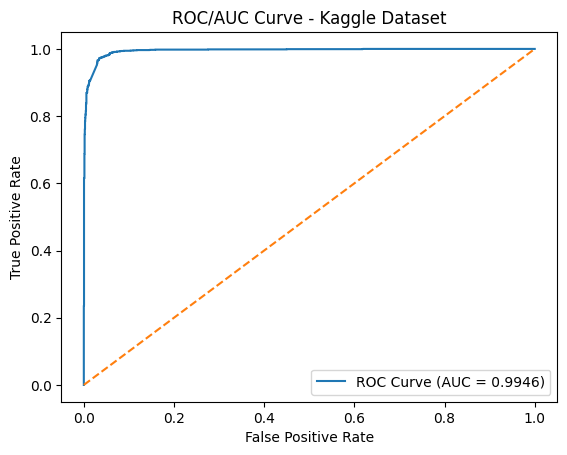

AUC: 0.9945702603539325


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob_kag = model_kag.predict(X_test_pad_kag).ravel()

fpr, tpr, thresholds = roc_curve(y_test_kag, y_pred_prob_kag)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC/AUC Curve - Kaggle Dataset")
plt.legend()
plt.show()

print("AUC:", roc_auc)

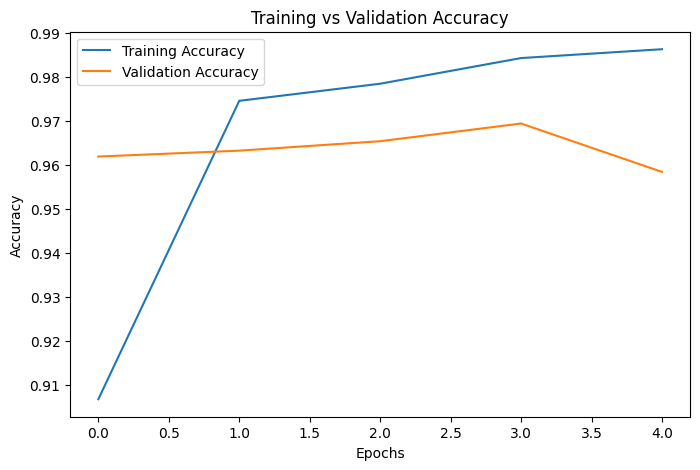

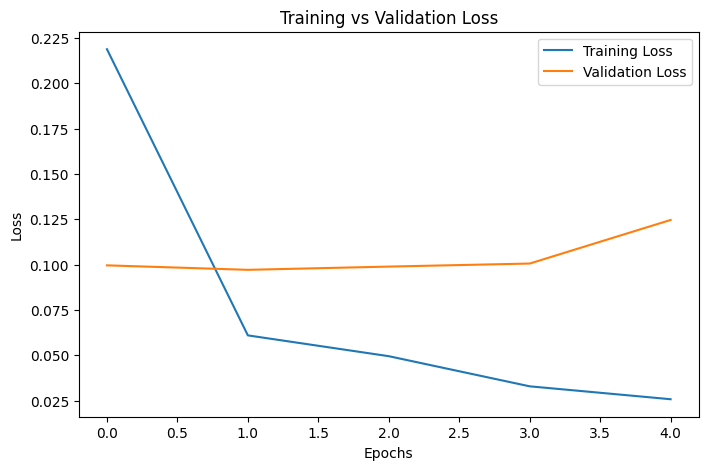

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history_kag.history['accuracy'], label='Training Accuracy')
plt.plot(history_kag.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history_kag.history['loss'], label='Training Loss')
plt.plot(history_kag.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

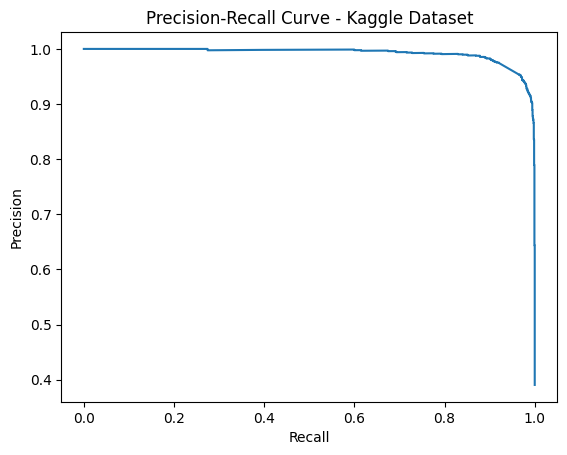

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test_kag, y_pred_probs)

plt.figure()

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Kaggle Dataset")

plt.show()

In [ ]:
pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 367.4 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


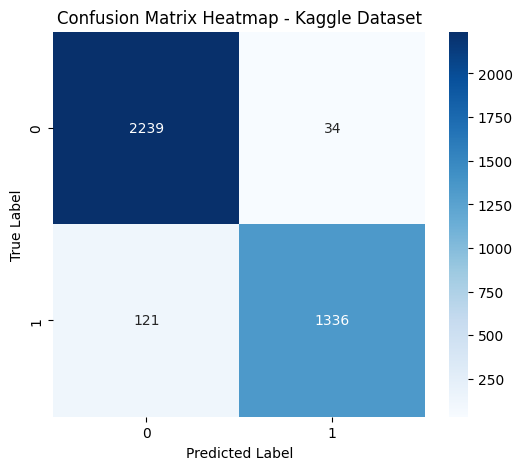

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_kag, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap - Kaggle Dataset")

plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import time

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

start_train = time.time()

history_kag = model_kag.fit(
    X_train_pad_kag,
    y_train_kag,
    epochs=10,
    validation_data=(X_test_pad_kag, y_test_kag),
    callbacks=[early_stop]
)

end_train = time.time()

training_time_kag = end_train - start_train

print("Training Time:", training_time_kag)

Epoch 1/10
467/467 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.9855 - loss: 0.0267 - val_accuracy: 0.9579 - val_loss: 0.1134
Epoch 2/10
467/467 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.9849 - loss: 0.0273 - val_accuracy: 0.9662 - val_loss: 0.1239
Epoch 3/10
467/467 ━━━━━━━━━━━━━━━━━━━━ 50s 108ms/step - accuracy: 0.9856 - loss: 0.0282 - val_accuracy: 0.9614 - val_loss: 0.1255
Training Time: 147.36210250854492


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_kaggle_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

history_kag = model_kag.fit(
    X_train_pad_kag,
    y_train_kag,
    epochs=10,
    validation_data=(X_test_pad_kag, y_test_kag),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9851 - loss: 0.0266
Epoch 1: val_accuracy improved from None to 0.96836, saving model to best_kaggle_model.keras

Epoch 1: finished saving model to best_kaggle_model.keras
467/467 ━━━━━━━━━━━━━━━━━━━━ 48s 104ms/step - accuracy: 0.9853 - loss: 0.0270 - val_accuracy: 0.9684 - val_loss: 0.1186
Epoch 2/10
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9861 - loss: 0.0261
Epoch 2: val_accuracy improved from 0.96836 to 0.97051, saving model to best_kaggle_model.keras

Epoch 2: finished saving model to best_kaggle_model.keras
467/467 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - accuracy: 0.9851 - loss: 0.0279 - val_accuracy: 0.9705 - val_loss: 0.1128
Epoch 3/10
467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9843 - loss: 0.0263
Epoch 3: val_accuracy did not improve from 0.97051
467/467 ━━━━━━━━━━━━━━━━━━━━ 51s 110ms/step - accuracy: 0.9855 - loss: 0.0253 - val_accuracy: 0.9700 - val_loss: 0.1221
Epoch 4/10
467/467 

In [ ]:
import time

start_inf = time.time()

sample_pred = model_kag.predict(X_test_pad_kag[:1])

end_inf = time.time()

print("Inference time per sample:", end_inf - start_inf, "seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Inference time per sample: 0.11165428161621094 seconds


In [ ]:
import os

model_size = os.path.getsize("best_kaggle_model.keras") / (1024 * 1024)

print("Model size:", model_size, "MB")

Model size: 16.487499237060547 MB


In [ ]:
import psutil
import os

process = psutil.Process(os.getpid())

ram_usage = process.memory_info().rss / (1024 * 1024)

print("RAM usage:", ram_usage, "MB")

RAM usage: 1292.1640625 MB


In [ ]:
history_kag_batch = model_kag.fit(
    X_train_pad_kag,
    y_train_kag,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad_kag, y_test_kag),
    callbacks=[early_stop]
)

Epoch 1/5
234/234 ━━━━━━━━━━━━━━━━━━━━ 161s 687ms/step - accuracy: 0.9859 - loss: 0.0244 - val_accuracy: 0.9694 - val_loss: 0.1193
Epoch 2/5
234/234 ━━━━━━━━━━━━━━━━━━━━ 167s 712ms/step - accuracy: 0.9855 - loss: 0.0250 - val_accuracy: 0.9614 - val_loss: 0.1380


In [ ]:
import time

start_tp = time.time()

preds = model_kag.predict(X_test_pad_kag)

end_tp = time.time()

throughput = len(X_test_pad_kag) / (end_tp - start_tp)

print("Throughput:", throughput, "samples/second")

117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step
Throughput: 272.46896204028803 samples/second


In [ ]:
import psutil

cpu_usage = psutil.cpu_percent(interval=1)

print("CPU Usage:", cpu_usage, "%")

CPU Usage: 8.6 %


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


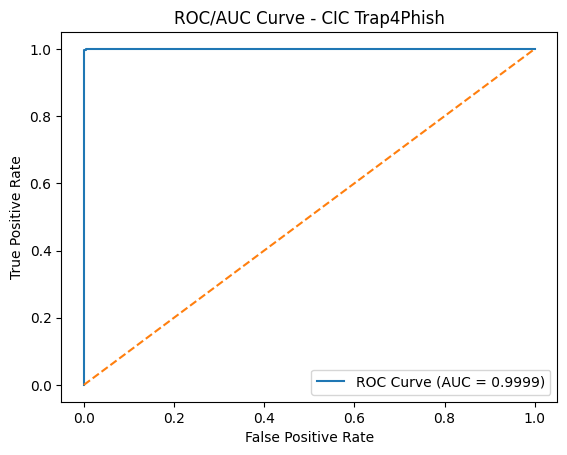

AUC: 0.9999369943137368


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob_trap = model_trap.predict(X_test_trap_cnn).ravel()

fpr_trap, tpr_trap, thresholds_trap = roc_curve(y_test_trap, y_pred_prob_trap)
auc_trap = auc(fpr_trap, tpr_trap)

plt.figure()
plt.plot(fpr_trap, tpr_trap, label=f"ROC Curve (AUC = {auc_trap:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC/AUC Curve - CIC Trap4Phish")
plt.legend()
plt.show()

print("AUC:", auc_trap)

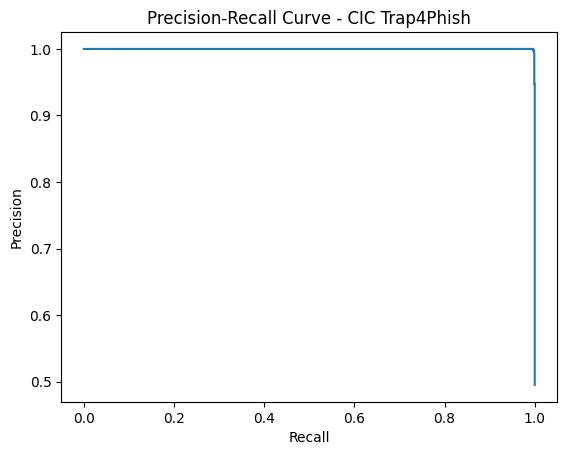

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_trap, recall_trap, _ = precision_recall_curve(
    y_test_trap,
    y_pred_prob_trap
)

plt.figure()

plt.plot(recall_trap, precision_trap)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - CIC Trap4Phish")

plt.show()

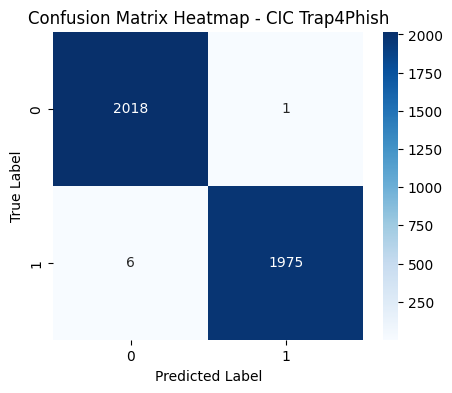

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_trap = (y_pred_prob_trap > 0.5).astype(int)

cm_trap = confusion_matrix(y_test_trap, y_pred_trap)

plt.figure(figsize=(5,4))

sns.heatmap(cm_trap, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap - CIC Trap4Phish")

plt.show()

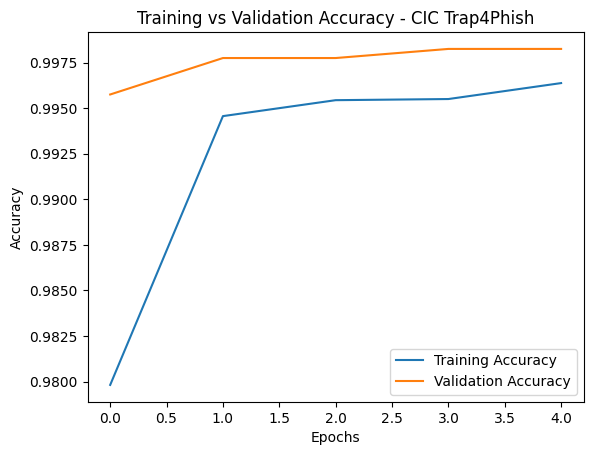

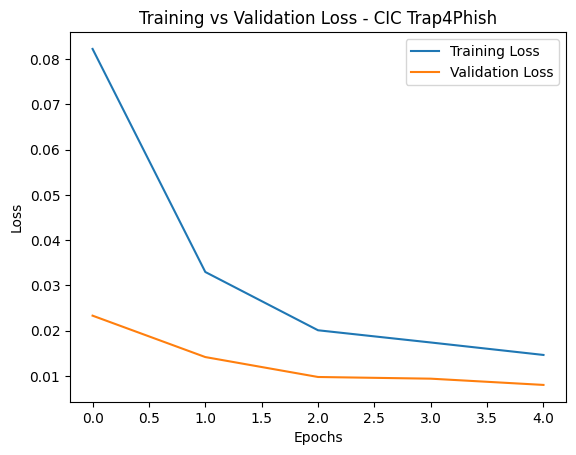

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history_trap.history['accuracy'], label='Training Accuracy')
plt.plot(history_trap.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy - CIC Trap4Phish')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

# Loss plot
plt.plot(history_trap.history['loss'], label='Training Loss')
plt.plot(history_trap.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss - CIC Trap4Phish')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [ ]:
import time

start_inf = time.time()

sample_pred_trap = model_trap.predict(X_test_trap_cnn[:1])

end_inf = time.time()

print("Inference time per sample:", end_inf - start_inf, "seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
Inference time per sample: 1.0809926986694336 seconds


In [ ]:
import time

start_tp = time.time()

preds_trap = model_trap.predict(X_test_trap_cnn)

end_tp = time.time()

throughput_trap = len(X_test_trap_cnn) / (end_tp - start_tp)

print("Throughput:", throughput_trap, "samples/second")

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Throughput: 1214.4256301095502 samples/second


In [ ]:
model_trap.save("trap4phish_model.h5")

In [ ]:
import os

size_mb = os.path.getsize("trap4phish_model.h5") / (1024 * 1024)

print("Model Size:", size_mb, "MB")

Model Size: 0.22332763671875 MB


In [ ]:
import psutil
import os

process = psutil.Process(os.getpid())

ram_usage_mb = process.memory_info().rss / (1024 * 1024)

print("RAM Usage:", ram_usage_mb, "MB")

RAM Usage: 1410.61328125 MB


In [ ]:
import os

spam_path = "Datasets/spamassassin"

print(os.listdir(spam_path))

['20021010_easy_ham.tar.bz2', '20021010_easy_ham', '20021010_spam', '20021010_spam.tar.bz2']


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob_spam = model.predict(X_test_padded)

fpr_spam, tpr_spam, _ = roc_curve(y_test, y_pred_prob_spam)

auc_spam = auc(fpr_spam, tpr_spam)

plt.plot(fpr_spam, tpr_spam, label=f"ROC Curve (AUC = {auc_spam:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC/AUC Curve - SpamAssassin")
plt.legend()

plt.show()

print("AUC:", auc_spam)

NameError: name 'X_test_padded' is not defined

In [ ]:
print(X_train.shape)
print(X_test.shape)

(2441,)
(611,)


In [ ]:
print(type(X_test))

<class 'pandas.Series'>


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_test_seq = tokenizer.texts_to_sequences(X_test)

X_test_pad = pad_sequences(X_test_seq, maxlen=200)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


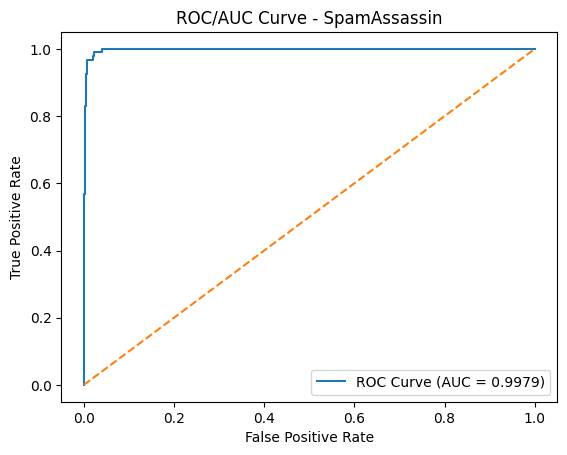

AUC: 0.9978784169726642


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob_spam = model.predict(X_test_pad)

fpr_spam, tpr_spam, _ = roc_curve(y_test, y_pred_prob_spam)

auc_spam = auc(fpr_spam, tpr_spam)

plt.plot(fpr_spam, tpr_spam, label=f"ROC Curve (AUC = {auc_spam:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC/AUC Curve - SpamAssassin")
plt.legend()

plt.show()

print("AUC:", auc_spam)

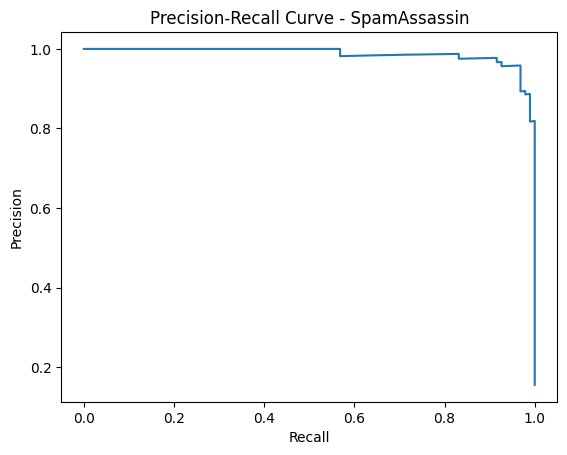

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob_spam)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SpamAssassin")

plt.show()

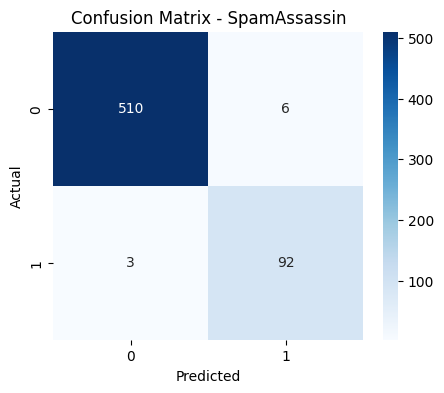

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_spam = (y_pred_prob_spam > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_spam)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SpamAssassin")

plt.show()

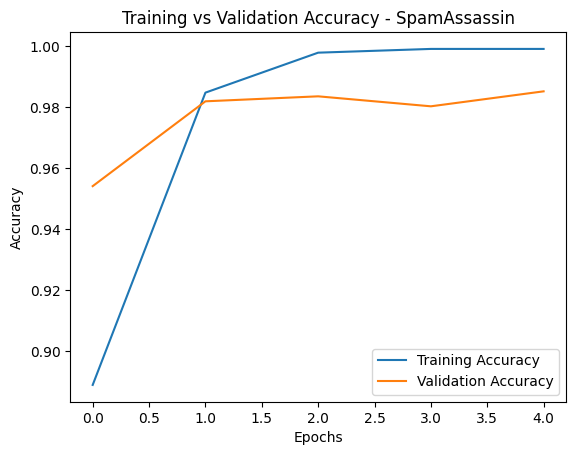

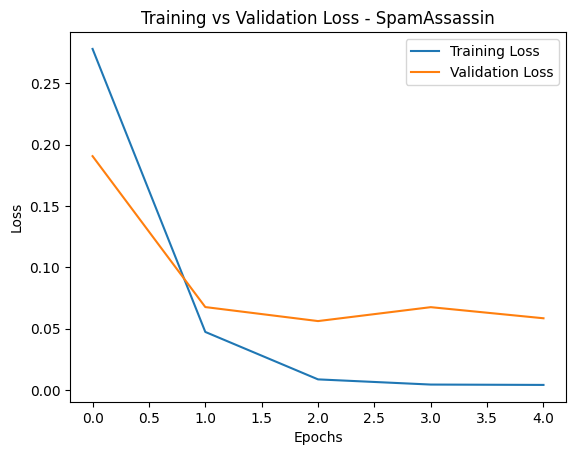

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy - SpamAssassin')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss - SpamAssassin')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=200)
X_test_padded = pad_sequences(X_test_seq, maxlen=200)

print(X_test_padded.shape)

(611, 200)


In [ ]:
import time

start_inf = time.time()

sample_pred_spam = model.predict(X_test_padded[:1])

end_inf = time.time()

print("Inference time per sample:", end_inf - start_inf, "seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Inference time per sample: 0.09480690956115723 seconds


In [ ]:
import time

start_tp = time.time()

preds_spam = model.predict(X_test_padded)

end_tp = time.time()

throughput_spam = len(X_test_padded) / (end_tp - start_tp)

print("Throughput:", throughput_spam, "samples/second")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Throughput: 1648.6131890612235 samples/second


In [ ]:
model.save("spamassassin_model.h5")

import os

size_mb = os.path.getsize("spamassassin_model.h5") / (1024 * 1024)

print("Model Size:", size_mb, "MB")

Model Size: 15.737991333007812 MB


In [ ]:
import psutil
import os

process = psutil.Process(os.getpid())

ram_usage_mb = process.memory_info().rss / (1024 * 1024)

print("RAM Usage:", ram_usage_mb, "MB")

RAM Usage: 1421.703125 MB


In [ ]:
import psutil
cpu_usage_trap = psutil.cpu_percent(interval=1)
print("CPU Usage:", cpu_usage_trap, "%")

CPU Usage: 7.9 %


In [ ]:
import psutil
cpu_usage_spam = psutil.cpu_percent(interval=1)
print("CPU Usage:", cpu_usage_spam, "%")

CPU Usage: 7.1 %


In [ ]:
model_kag.save("kaggle_text_model.keras")

In [ ]:
model_trap.save("trap4phish_model.keras")

In [ ]:
model.save("spamassassin_model.keras")

In [ ]:
import pickle
with open("kaggle_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer_kag, f)

In [ ]:
import pickle

with open("spamassassin_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
import pickle

with open("trap4phish_scaler.pkl", "wb") as f:
    pickle.dump(scaler_trap, f)